<a href="https://colab.research.google.com/github/Tamaki-Baba/text-mining/blob/main/4_2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Download polarity dataset chABSA-dataset (https://www.kaggle.com/datasets/takahirokubo0/chabsa?resource=download)
(https://www.tis.co.jp/news/2018/tis_news/20180410_1.html), then count the number of tokens and words in the ‘sentence’ column, and plot a graph sorted by word frequency in descendant order.

In [ ]:
import numpy as np
import pandas as pd
from os import path
from PIL import Image
import os
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt
import json
import spacy
from collections import Counter

In [ ]:
!wget https://s3-ap-northeast-1.amazonaws.com/dev.tech-sketch.jp/chakki/public/chABSA-dataset.zip

--2025-05-16 03:54:10--  https://s3-ap-northeast-1.amazonaws.com/dev.tech-sketch.jp/chakki/public/chABSA-dataset.zip
Resolving s3-ap-northeast-1.amazonaws.com (s3-ap-northeast-1.amazonaws.com)... 3.5.154.20, 52.219.152.156, 52.219.172.68, ...
Connecting to s3-ap-northeast-1.amazonaws.com (s3-ap-northeast-1.amazonaws.com)|3.5.154.20|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 722777 (706K) [application/zip]
Saving to: ‘chABSA-dataset.zip’

chABSA-dataset.zip  100%[===================>] 705.84K   747KB/s    in 0.9s    

2025-05-16 03:54:12 (747 KB/s) - ‘chABSA-dataset.zip’ saved [722777/722777]



In [ ]:
!unzip chABSA-dataset.zip

Archive:  chABSA-dataset.zip
   creating: chABSA-dataset/
  inflating: chABSA-dataset/.DS_Store  
   creating: __MACOSX/
   creating: __MACOSX/chABSA-dataset/
  inflating: __MACOSX/chABSA-dataset/._.DS_Store  
 extracting: chABSA-dataset/.gitkeep  
  inflating: chABSA-dataset/e00008_ann.json  
  inflating: chABSA-dataset/e00017_ann.json  
  inflating: chABSA-dataset/e00024_ann.json  
  inflating: chABSA-dataset/e00026_ann.json  
  inflating: chABSA-dataset/e00030_ann.json  
  inflating: chABSA-dataset/e00033_ann.json  
  inflating: chABSA-dataset/e00034_ann.json  
  inflating: chABSA-dataset/e00035_ann.json  
  inflating: chABSA-dataset/e00037_ann.json  
  inflating: chABSA-dataset/e00051_ann.json  
  inflating: chABSA-dataset/e00053_ann.json  
  inflating: chABSA-dataset/e00058_ann.json  
  inflating: chABSA-dataset/e00069_ann.json  
  inflating: chABSA-dataset/e00091_ann.json  
  inflating: chABSA-dataset/e00107_ann.json  
  inflating: chABSA-dataset/e00114_ann.json  
  inflating: ch

In [ ]:
# SpaCyの日本語モデルをインポート
!pip install -U spacy
!python -m spacy download ja_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 102.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 71.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ja_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
nlp = spacy.load("ja_core_news_sm")

In [ ]:
# JSONファイルから文を抽出する関数
def getSentence(path):
    """
    input:
        path: (string) path to a JSON file in the chABSA dataset
    returns:
        sentences: (list of string) sentences in this file
    """
    try:
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)  # JSONを読み込み
    except:
        print("file cannot be found")
        return []

    sentences = []
    tmp = data["sentences"]  # "sentences"フィールドから抽出
    for obj in tmp:
        sentences.append(obj["sentence"])  # 各文をリストに追加

    return sentences

In [ ]:
sentences = getSentence("/content/chABSA-dataset/e00008_ann.json")
print(sentences)

['当連結会計年度におけるわが国経済は、政府の経済政策や日銀の金融緩和策により、企業業績、雇用・所得環境は改善し、景気も緩やかな回復基調のうちに推移いたしましたが、中国をはじめとするアジア新興国経済の減速懸念や、英国の欧州連合（ＥＵ）離脱決定、米国新政権への移行など、引き続き先行きは不透明な状況となっております', '当社グループを取り巻く環境は、実質賃金が伸び悩むなか、消費者の皆様の生活防衛意識の高まりや節約志向により、個人消費は本格的な改善には至らず、また少子高齢化、人口減少による社会構造の変化、雇用改善に伴う労働コストの上昇、企業間競争の激化など、引き続き厳しい状況となりました', 'このような環境の中、当社グループはきのこ事業を中心として、健康食材である「きのこ」の研究開発、生産、販売を通して、より多くの皆様へ、おいしさと健康をお届けできるよう事業活動を行ってまいりました', 'また、平成26年に策定いたしました中期経営計画の見直しを行い、市況に左右されない事業ポートフォリオの構築を目指した活動を推進し、おいしくて健康な「きのこ食文化の創造」と「企業の発展」に向け邁進してまいりました', '以上の結果、当連結会計年度の当社グループの業績は、売上高631億19百万円（前期比3.5％増）、営業利益34億30百万円（前期比0.1％増）、経常利益43億79百万円（前期比7.5％増）、親会社株主に帰属する当期純利益は28億28百万円（前期比8.9％増）となりました', 'なお、当連結会計年度の生産量は、ブナピーを含めブナシメジ42,602ｔ（同5.5％増）、エリンギ19,250ｔ（同0.2％減）、マイタケ14,281ｔ（同4.3％増）となりました', '当連結会計年度の各セグメントの概況は次のとおりであります', '「国内きのこ事業」', '生産部門におきましては、衛生管理を徹底し、安定栽培と品質の向上に努めてまいりました', '平成27年４月の火災により生産を休止していた苫小牧第一きのこセンターが、工場を再建し、平成28年４月27日よりブナシメジの収穫・出荷を再開したことや、カットブナシメジ専用工場として新設した富山きのこセンターが平成28年９月上旬から収穫・出荷を開始したことにより、ブナシメジの生産量は増加いたしました', 'また、改修のため一時生産を休止しており

In [ ]:
# トークン化と頻度解析
tokens = []
for sentence in sentences:
    doc = nlp(sentence)
    tokens.extend([token.text for token in doc if not token.is_punct and not token.is_space])

In [ ]:
# 単語頻度を計算
word_freq = Counter(tokens)

In [ ]:
# DataFrameに変換してソート
df_word_freq = pd.DataFrame(word_freq.items(), columns=['Word', 'Frequency']).sort_values(by='Frequency', ascending=False)

In [ ]:
!apt-get -y install fonts-ipaexfont

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-ipaexfont is already the newest version (00401-3ubuntu1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


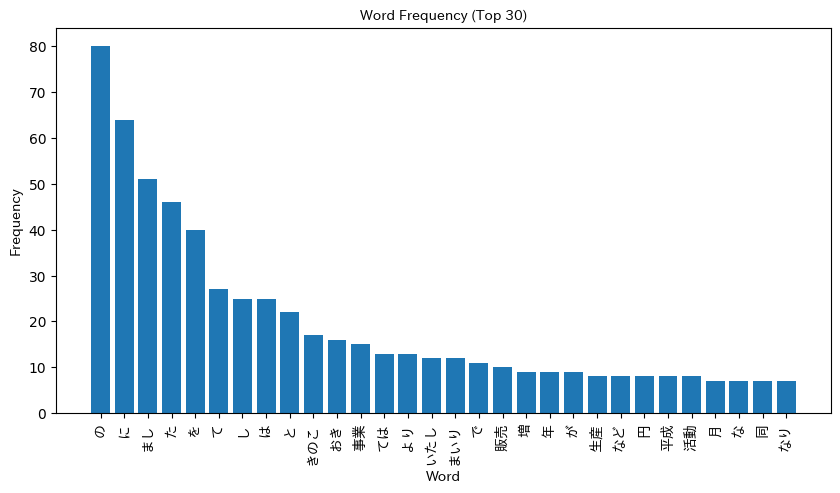

In [ ]:
# 日本語グラフをプロット
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# IPAフォントパスを設定
font_path = '/usr/share/fonts/opentype/ipaexfont-gothic/ipaexg.ttf'
ipaex_font = fm.FontProperties(fname=font_path)

plt.figure(figsize=(10, 5))
plt.bar(df_word_freq['Word'][:30], df_word_freq['Frequency'][:30])  # トップ30
plt.xticks(rotation=90, fontproperties=ipaex_font)  # X軸の日本語フォントを設定
plt.xlabel('Word', fontproperties=ipaex_font)  # Xラベルのフォントを設定
plt.ylabel ('Frequency', fontproperties=ipaex_font)  # Yラベルのフォントを設定
plt.title('Word Frequency (Top 30)', fontproperties=ipaex_font)  # タイトルのフォントを設定
plt.show()